# Структура данных, визуализация и параметры сигналов

В ноутбуке выполнены три задания:

1. Исследовать сигналы, исключённые как выбросы, и изучить их форму.
2. Выбрать сигналы с близкой амплитудой в пределах 0,5%, построить их графики и сравнить форму.
3. Повторить сравнение в нескольких диапазонах амплитуд.

Источник данных: `data_4W_sem.csv`. Все расчёты и графики находятся непосредственно в этом ноутбуке.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (13, 6), "font.size": 12})

DATA_PATH = Path("data_4W_sem.csv")
BASELINE_BINS = 80
SIMILARITY_TOLERANCE = 0.005
OUTLIER_THRESHOLD_MAD = 5.0

## 1. Загрузка и структура данных

Каждая строка CSV представляет один сигнал, каждый столбец — последовательный временной отсчёт. Сначала проверим размер, пропуски и число уникальных форм.

In [2]:
raw = pd.read_csv(DATA_PATH, header=None)
values = raw.to_numpy(dtype=float)

summary = pd.DataFrame({
    "Показатель": ["Число сигналов", "Отсчётов в сигнале", "Пропущенных значений", "Уникальных форм", "Доля повторов"],
    "Значение": [
        values.shape[0],
        values.shape[1],
        int(raw.isna().sum().sum()),
        int(len(raw.drop_duplicates())),
        f"{100 * (1 - len(raw.drop_duplicates()) / len(raw)):.1f}%",
    ],
})
display(summary)

,Показатель,Значение
0,Число сигналов,3000
1,Отсчётов в сигнале,500
2,Пропущенных значений,0
3,Уникальных форм,583
4,Доля повторов,80.6%


**Промежуточный вывод.** В наборе 3000 строк по 500 отсчётов и нет пропусков. При этом присутствуют только 583 уникальные формы: 80,6% строк являются точными повторами. Чтобы частые дубликаты не влияли на статистику формы сильнее остальных сигналов, поиск выбросов и подбор близких форм выполняются по уникальным сигналам. Затем результаты переносятся на все исходные строки.

## 2. Подготовка и параметры формы

Для каждого уникального сигнала:

- базовая линия оценивается медианой первых 80 отсчётов;
- амплитуда равна максимуму после вычитания базовой линии;
- `peak_bin` — положение максимума;
- `FWHM` — ширина импульса на половине высоты;
- нормированная площадь равна площади положительной части сигнала, делённой на амплитуду;
- `tail_ratio` сравнивает площадь хвоста после максимума с площадью фронта перед максимумом.

Эти показатели описывают не только высоту, но также положение, ширину и асимметрию импульса.

In [3]:
def signal_features(signal):
    amplitude = float(signal.max())
    peak = int(signal.argmax())
    half_height = amplitude / 2

    left_candidates = np.flatnonzero(signal[:peak + 1] <= half_height)
    left = int(left_candidates[-1]) if left_candidates.size else 0
    right_candidates = np.flatnonzero(signal[peak:] <= half_height)
    right = peak + int(right_candidates[0]) if right_candidates.size else len(signal) - 1

    positive = np.clip(signal, 0, None)
    normalized_area = float(positive.sum() / max(amplitude, 1e-12))
    leading_area = float(positive[max(0, peak - 50):peak + 1].sum())
    trailing_area = float(positive[peak:min(len(signal), peak + 150)].sum())
    tail_ratio = trailing_area / max(leading_area, 1e-12)

    return amplitude, peak, right - left, normalized_area, tail_ratio


def robust_z_scores(matrix):
    median = np.median(matrix, axis=0)
    mad = 1.4826 * np.median(np.abs(matrix - median), axis=0)
    mad[mad == 0] = 1.0
    return np.abs((matrix - median) / mad)


first_occurrence = ~raw.duplicated()
unique_raw = raw.loc[first_occurrence]
first_original_indices = unique_raw.index.to_numpy()
unique_values = unique_raw.to_numpy(dtype=float)

baselines = np.median(unique_values[:, :BASELINE_BINS], axis=1)
signals = unique_values - baselines[:, None]

metric_names = ["amplitude", "peak_bin", "fwhm", "normalized_area", "tail_ratio"]
metric_values = np.array([signal_features(row) for row in signals])
features = pd.DataFrame(metric_values, columns=metric_names)
features[["peak_bin", "fwhm"]] = features[["peak_bin", "fwhm"]].astype(int)
features.insert(0, "unique_shape_id", np.arange(len(features)))
features.insert(1, "first_original_index", first_original_indices)

row_keys = [row.tobytes() for row in np.ascontiguousarray(values)]
unique_keys = [row.tobytes() for row in np.ascontiguousarray(unique_values)]
key_to_unique = {key: idx for idx, key in enumerate(unique_keys)}
unique_ids = np.array([key_to_unique[key] for key in row_keys])
features["repeat_count"] = np.bincount(unique_ids, minlength=len(unique_values))

display(features.head())

,unique_shape_id,first_original_index,amplitude,peak_bin,fwhm,normalized_area,tail_ratio,repeat_count
0,0,0,163.421316,164,145,144.707229,3.199704,7
1,1,1,107.085340,164,91,91.855481,2.288427,7
2,2,2,1.960420,135,2,74.958569,4.965904,9
3,3,3,182.164043,161,138,139.272887,3.238453,4
4,4,4,125.840122,166,92,92.003680,2.084755,8


## Задача 1. Исследование выбросов

Сохранённой маски ранее исключённых сигналов в проекте нет, поэтому применяется явный воспроизводимый критерий. Для пяти параметров формы вычисляется робастное отклонение от медианы в единицах MAD. Сигнал считается выбросом, если хотя бы один параметр отличается более чем на 5 MAD.

Порог 5 MAD выбран строгим: он выделяет явно нетипичные формы и не отбрасывает нормальные различия между тремя основными семействами импульсов.

In [4]:
features["robust_distance"] = robust_z_scores(metric_values).max(axis=1)
features["is_outlier"] = features["robust_distance"] > OUTLIER_THRESHOLD_MAD

outliers = features.loc[features["is_outlier"]].copy()
outlier_original_indices = np.flatnonzero(np.isin(unique_ids, outliers["unique_shape_id"]))

print(f"Уникальных выбросов: {len(outliers)}")
print(f"Строк-выбросов с учётом повторов: {len(outlier_original_indices)}")
print("Индексы исходных строк:", outlier_original_indices.tolist())
display(outliers.round(3))

Уникальных выбросов: 2
Строк-выбросов с учётом повторов: 13
Индексы исходных строк: [2, 16, 375, 388, 396, 691, 859, 1574, 1580, 2079, 2211, 2617, 2628]


,unique_shape_id,first_original_index,amplitude,peak_bin,fwhm,normalized_area,tail_ratio,repeat_count,robust_distance,is_outlier
2,2,2,1.960,135,2,74.959,4.966,9,9.780,True
291,291,396,2.453,141,3,116.302,2.282,4,7.757,True


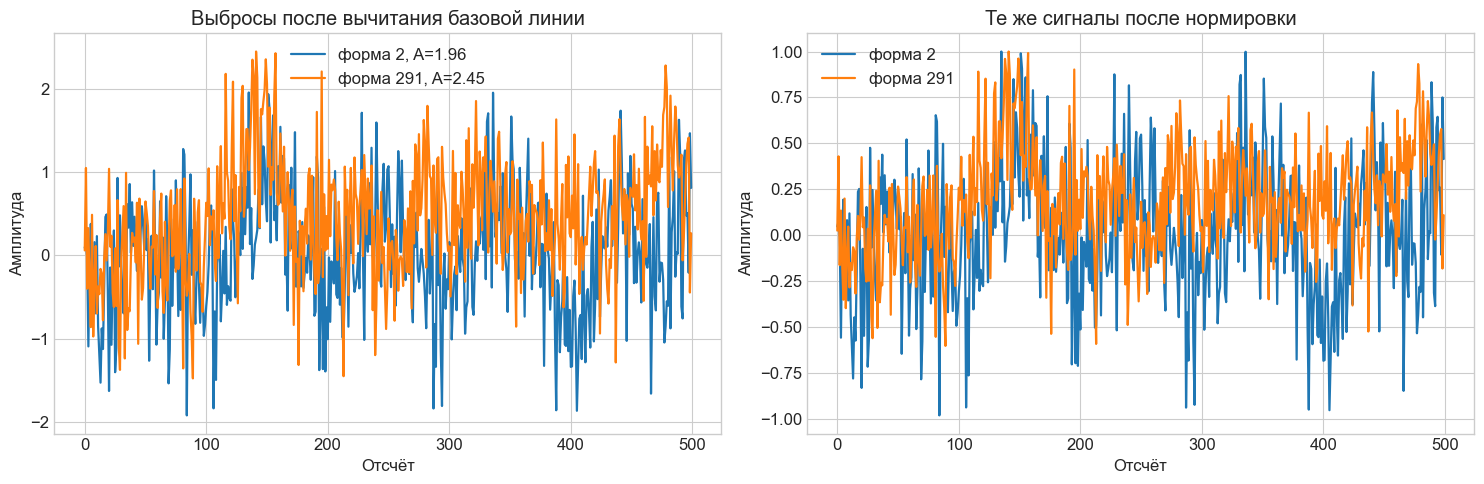

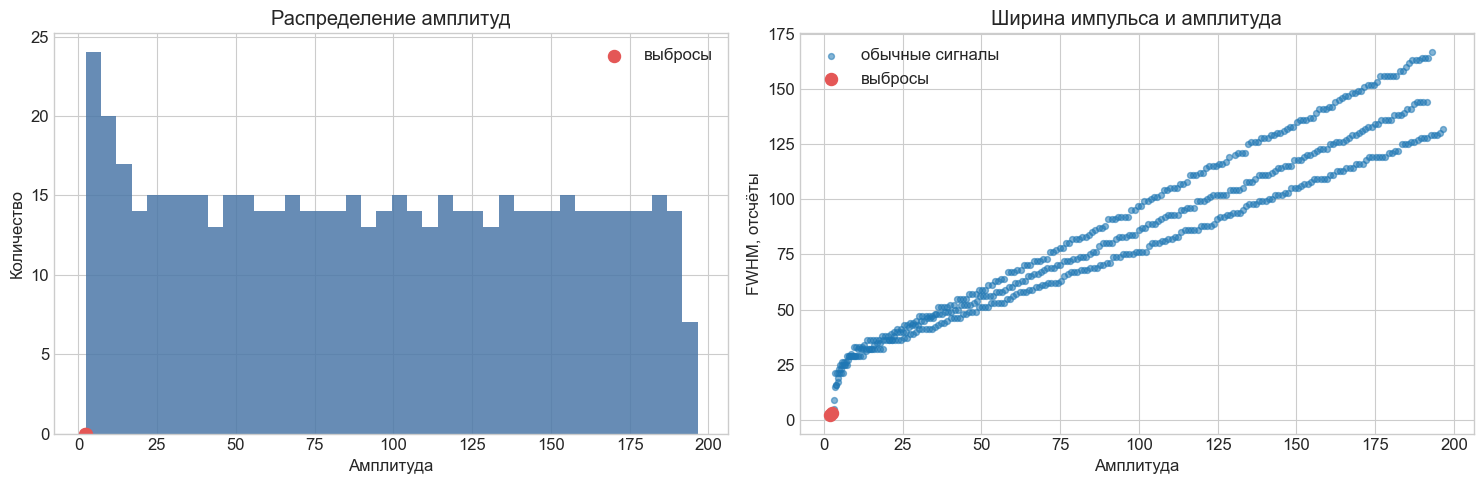

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx in outliers.index:
    amplitude = features.loc[idx, "amplitude"]
    axes[0].plot(signals[idx], lw=1.6, label=f"форма {idx}, A={amplitude:.2f}")
    axes[1].plot(signals[idx] / amplitude, lw=1.6, label=f"форма {idx}")

axes[0].set_title("Выбросы после вычитания базовой линии")
axes[1].set_title("Те же сигналы после нормировки")
for ax in axes:
    ax.set_xlabel("Отсчёт")
    ax.set_ylabel("Амплитуда")
    ax.legend()
plt.tight_layout()
plt.show()

normal = features.loc[~features["is_outlier"]]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(normal["amplitude"], bins=40, color="#4c78a8", alpha=0.85)
axes[0].scatter(outliers["amplitude"], np.zeros(len(outliers)), color="#e45756", s=75, label="выбросы")
axes[0].set(title="Распределение амплитуд", xlabel="Амплитуда", ylabel="Количество")
axes[0].legend()

axes[1].scatter(normal["amplitude"], normal["fwhm"], s=18, alpha=0.55, label="обычные сигналы")
axes[1].scatter(outliers["amplitude"], outliers["fwhm"], s=75, color="#e45756", label="выбросы")
axes[1].set(title="Ширина импульса и амплитуда", xlabel="Амплитуда", ylabel="FWHM, отсчёты")
axes[1].legend()
plt.tight_layout()
plt.show()

### Вывод по задаче 1

Обнаружены две уникальные аномальные формы с амплитудами 1,960 и 2,453. Они встречаются соответственно 9 и 4 раза, поэтому выбросами помечены 13 исходных строк: `2, 16, 375, 388, 396, 691, 859, 1574, 1580, 2079, 2211, 2617, 2628`.

Обе формы имеют максимум на отсчётах 135–141 и ширину FWHM всего 2–3 отсчёта. У обычных импульсов медианная ширина равна 82 отсчётам. На графике выбросы выглядят как шумовые колебания без устойчивого широкого импульса. Их ранний узкий максимум создаётся отдельным шумовым пиком, а не типичной формой события. Поэтому исключение этих сигналов обосновано одновременно малой амплитудой, аномальным положением максимума и очень малой шириной.

## Задача 2. Сигналы с амплитудой в пределах 0,5%

Для каждой допустимой уникальной формы считается число соседей, чья амплитуда отличается не более чем на 0,5%. Опорным выбирается сигнал с самой заполненной окрестностью. Это даёт несколько различных форм при практически одинаковой высоте импульса.

In [6]:
def choose_dense_reference(amplitudes, mask, tolerance=SIMILARITY_TOLERANCE):
    candidates = np.flatnonzero(mask)
    counts = np.array([
        np.sum(mask & (np.abs(amplitudes - amplitudes[i]) <= tolerance * amplitudes[i]))
        for i in candidates
    ])
    reference = int(candidates[np.argmax(counts)])
    group = mask & (np.abs(amplitudes - amplitudes[reference]) <= tolerance * amplitudes[reference])
    return reference, group


amplitudes = features["amplitude"].to_numpy()
good = ~features["is_outlier"].to_numpy()
reference, similar_mask = choose_dense_reference(amplitudes, good)
similar = features.loc[similar_mask].copy()
similar["relative_difference_pct"] = (
    100 * np.abs(similar["amplitude"] - amplitudes[reference]) / amplitudes[reference]
)

print(f"Опорная амплитуда: {amplitudes[reference]:.3f}")
print(f"Уникальных форм: {len(similar)}")
print(f"Строк с учётом повторов: {int(similar['repeat_count'].sum())}")
display(similar[["unique_shape_id", "amplitude", "relative_difference_pct", "peak_bin", "fwhm", "tail_ratio", "repeat_count"]].round(3))

Опорная амплитуда: 163.421
Уникальных форм: 5
Строк с учётом повторов: 32


,unique_shape_id,amplitude,relative_difference_pct,peak_bin,fwhm,tail_ratio,repeat_count
0,0,163.421,0.000,164,145,3.200,7
34,34,163.654,0.142,164,126,2.845,9
41,41,163.827,0.248,160,113,3.154,7
324,324,162.796,0.383,160,113,3.149,4
347,347,162.633,0.483,164,126,2.841,5


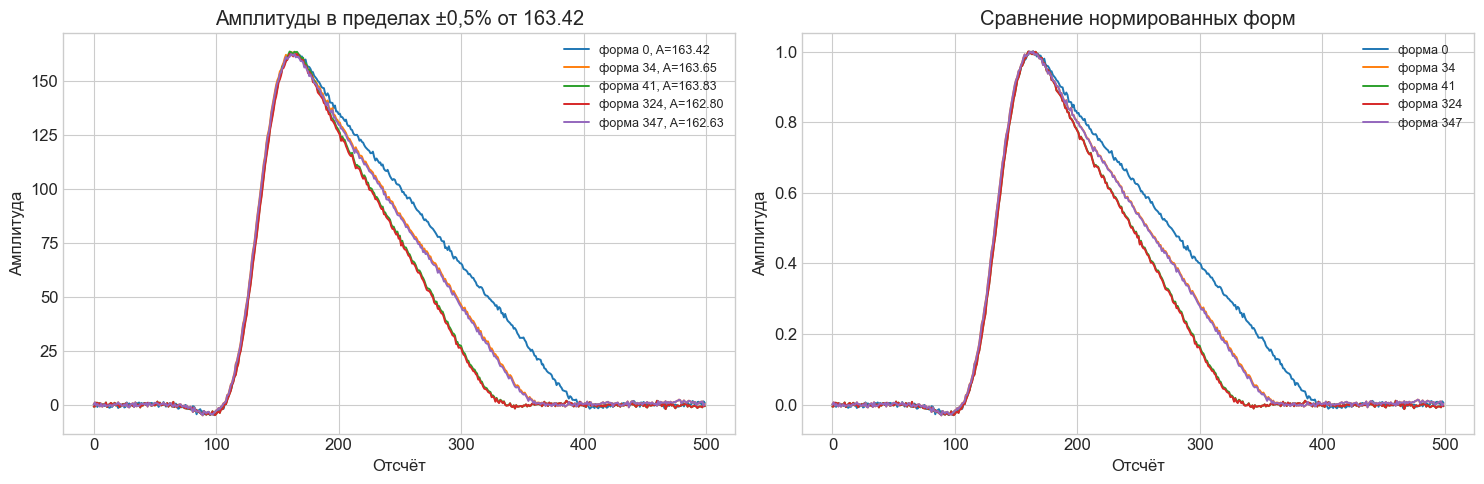

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for idx in np.flatnonzero(similar_mask):
    amplitude = features.loc[idx, "amplitude"]
    axes[0].plot(signals[idx], lw=1.4, label=f"форма {idx}, A={amplitude:.2f}")
    axes[1].plot(signals[idx] / amplitude, lw=1.4, label=f"форма {idx}")

axes[0].set_title(f"Амплитуды в пределах ±0,5% от {amplitudes[reference]:.2f}")
axes[1].set_title("Сравнение нормированных форм")
for ax in axes:
    ax.set_xlabel("Отсчёт")
    ax.set_ylabel("Амплитуда")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Вывод по задаче 2

В окрестность опорной амплитуды 163,421 вошли пять уникальных форм с максимальным различием 0,483%, или 32 строки с учётом повторов. Высота и положение вершины у них близки, но FWHM принимает значения 113, 126 и 145 отсчётов. Самый широкий сигнал спадает примерно до отсчёта 390, а более узкие — до 330–355.

Следовательно, одинаковая амплитуда не определяет форму сигнала однозначно. В данных существуют как минимум три семейства импульсов с разной длительностью спада. Для классификации событий одной амплитуды недостаточно: необходимо учитывать ширину, площадь и параметры хвоста.

## Задача 3. Сравнение в разных диапазонах амплитуд

Повторим подбор сигналов с допуском 0,5% отдельно в диапазонах `0–50`, `50–100`, `100–150` и `150–200`. В каждом диапазоне автоматически выбирается наиболее заполненная амплитудная окрестность.

In [8]:
amplitude_ranges = [(0, 50), (50, 100), (100, 150), (150, 200)]
range_groups = []
range_summary = []

for lo, hi in amplitude_ranges:
    range_mask = good & (amplitudes >= lo) & (amplitudes < hi)
    ref, group_mask = choose_dense_reference(amplitudes, range_mask)
    range_groups.append((lo, hi, ref, group_mask))
    selected = features.loc[group_mask]
    range_summary.append({
        "Диапазон": f"{lo}–{hi}",
        "Опорная амплитуда": amplitudes[ref],
        "Уникальных форм": int(group_mask.sum()),
        "Строк с повторами": int(selected["repeat_count"].sum()),
        "Минимальная FWHM": int(selected["fwhm"].min()),
        "Максимальная FWHM": int(selected["fwhm"].max()),
    })

range_summary = pd.DataFrame(range_summary)
display(range_summary.round(3))

,Диапазон,Опорная амплитуда,Уникальных форм,Строк с повторами,Минимальная FWHM,Максимальная FWHM
0,0–50,25.291,3,18,37,43
1,50–100,96.763,3,15,75,92
2,100–150,149.047,5,23,105,133
3,150–200,163.421,5,32,113,145


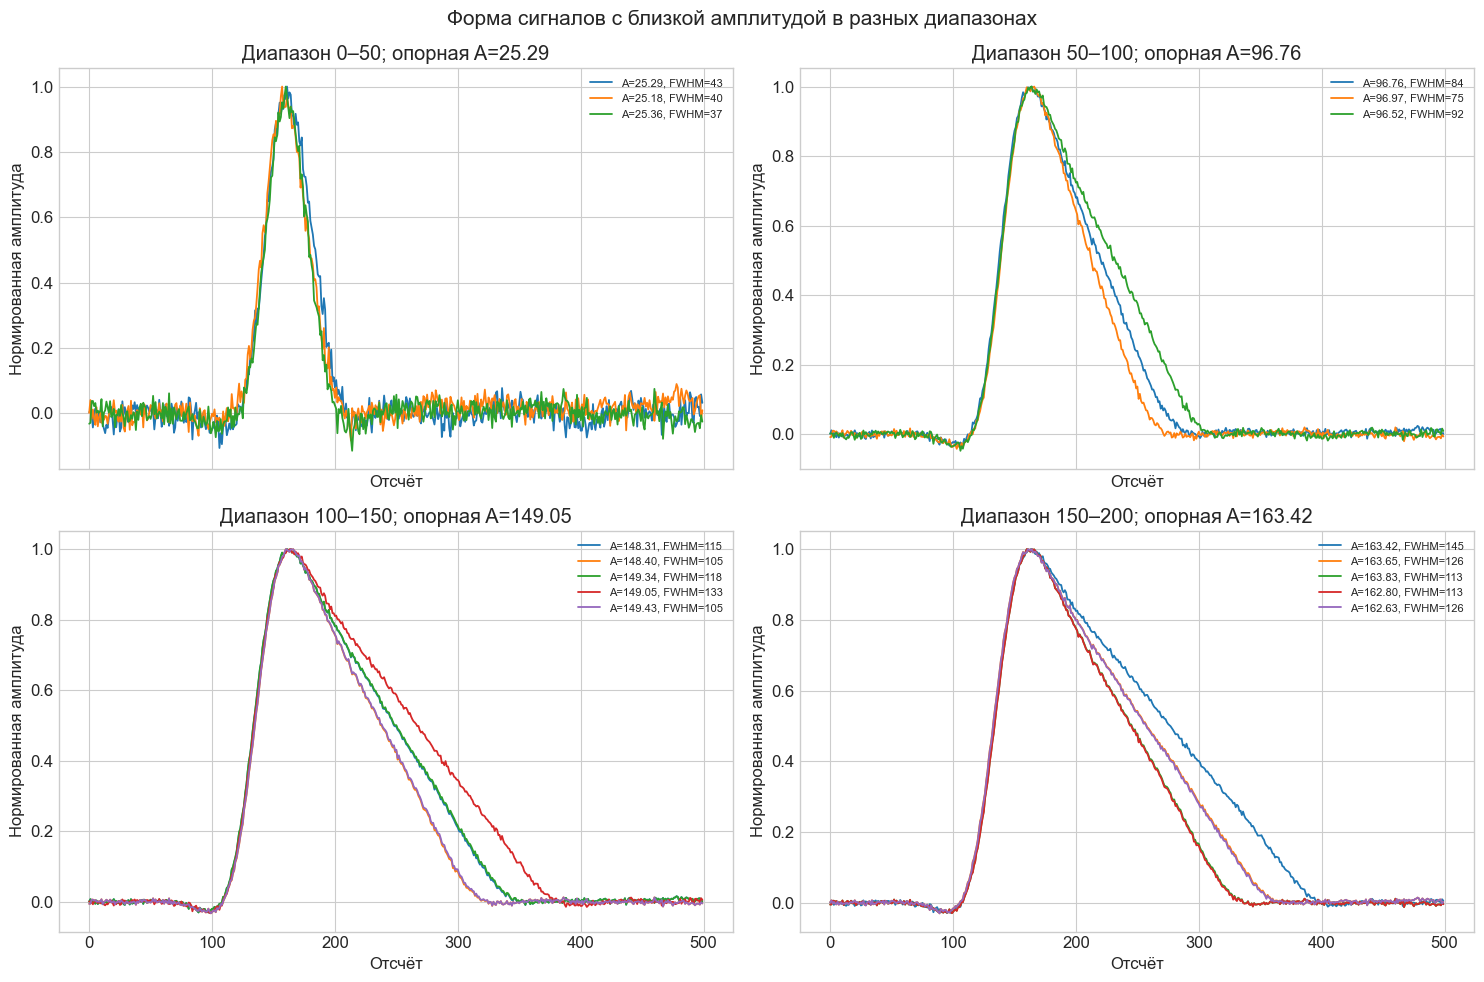

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

for ax, (lo, hi, ref, group_mask) in zip(axes.ravel(), range_groups):
    for idx in np.flatnonzero(group_mask):
        ax.plot(
            signals[idx] / features.loc[idx, "amplitude"],
            lw=1.3,
            label=f"A={features.loc[idx, 'amplitude']:.2f}, FWHM={features.loc[idx, 'fwhm']}"
        )
    ax.set_title(f"Диапазон {lo}–{hi}; опорная A={amplitudes[ref]:.2f}")
    ax.set_xlabel("Отсчёт")
    ax.set_ylabel("Нормированная амплитуда")
    ax.legend(fontsize=8)

fig.suptitle("Форма сигналов с близкой амплитудой в разных диапазонах", fontsize=15)
plt.tight_layout()
plt.show()

### Вывод по задаче 3

- **0–50.** Около амплитуды 25,291 выбраны три формы. Импульсы сравнительно узкие и сильнее зашумлены относительно высоты. Различия формы заметны преимущественно около вершины и сразу после неё.
- **50–100.** Около амплитуды 96,763 выбраны три формы. Шум относительно амплитуды уменьшается, а различия длительности спада становятся хорошо различимы.
- **100–150.** Около амплитуды 149,047 выбраны пять форм. Они имеют практически одинаковый фронт и вершину, но расходятся по ширине и положению окончания импульса.
- **150–200.** Около амплитуды 163,421 выбраны пять форм. Здесь особенно отчётливо видны три семейства ширины: примерно 113, 126 и 145 отсчётов.

Между амплитудой и FWHM наблюдается сильная положительная связь: коэффициент корреляции для нормальных уникальных сигналов равен примерно 0,970. С ростом амплитуды импульсы в среднем становятся шире. При этом внутри одного амплитудного диапазона остаются несколько ветвей, поэтому зависимость не является единственной линией.

## Общий вывод

1. Набор содержит много точных повторов, поэтому анализ формы необходимо проводить по 583 уникальным сигналам, а не напрямую по всем 3000 строкам.
2. Найдены две явно аномальные уникальные формы, повторённые в 13 строках. Это слабые шумоподобные сигналы с ранним узким максимумом и FWHM 2–3 отсчёта. Их исключение обосновано.
3. Сигналы с разницей амплитуды менее 0,5% могут существенно различаться по ширине и длительности спада. Амплитуда сама по себе не позволяет полностью описать форму.
4. Амплитуда и ширина тесно связаны: корреляция составляет около 0,970. Более высокие импульсы в среднем шире.
5. В данных видны несколько семейств формы с общим быстрым фронтом и различными хвостами. Для дальнейшей классификации разумно использовать совместно амплитуду, FWHM, нормированную площадь и отношение площадей хвоста и фронта.